<a href="https://colab.research.google.com/github/dbrzek/client_churn_prediction/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score

from sklearn.linear_model import LogisticRegression

# Oficjalny link
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

try:
    # Wczytanie danych do DataFrame
    df = pd.read_csv(url)
    print("Sukces! Dane wczytano pomyślnie.\n")

    # Wyświetlenie podstawowych informacji o zbiorze
    print(df.info())

except Exception as e:
    print(f"Wystąpił błąd podczas pobierania: {e}")

Sukces! Dane wczytano pomyślnie.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperles

In [3]:
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
mediana = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(mediana)

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df = df.drop("customerID", axis=1)

In [8]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


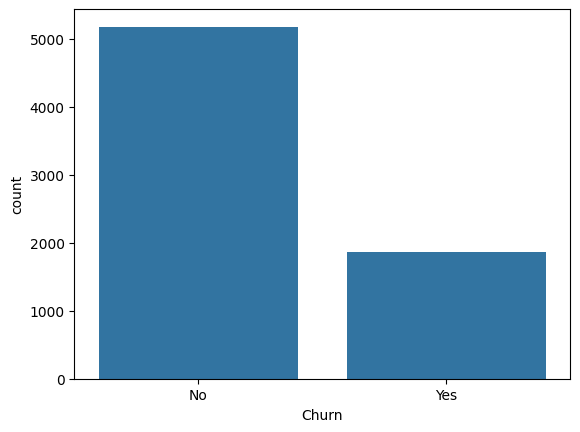

In [9]:
sns.countplot(x="Churn", data=df)
plt.show()

In [10]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}:")
        print(df[col].unique())

gender:
['Female' 'Male']
Partner:
['Yes' 'No']
Dependents:
['No' 'Yes']
PhoneService:
['No' 'Yes']
MultipleLines:
['No phone service' 'No' 'Yes']
InternetService:
['DSL' 'Fiber optic' 'No']
OnlineSecurity:
['No' 'Yes' 'No internet service']
OnlineBackup:
['Yes' 'No' 'No internet service']
DeviceProtection:
['No' 'Yes' 'No internet service']
TechSupport:
['No' 'Yes' 'No internet service']
StreamingTV:
['No' 'Yes' 'No internet service']
StreamingMovies:
['No' 'Yes' 'No internet service']
Contract:
['Month-to-month' 'One year' 'Two year']
PaperlessBilling:
['Yes' 'No']
PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn:
['No' 'Yes']


In [11]:
binary_map = {'No': 0, 'Yes': 1, 'No internet service': 0}

for col in df.columns:
    if df[col].dtype == 'object':
        unique_vals = set(df[col].dropna().unique())

        # check whether the column contains only these values
        if unique_vals.issubset(binary_map.keys()):
            df[col] = df[col].map(binary_map)

In [12]:
df['MultipleLines'] = df['MultipleLines'].map({'No': 0, 'Yes': 1, 'No phone service': 0})

In [13]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}:")
        print(df[col].unique())


gender:
['Female' 'Male']
InternetService:
['DSL' 'Fiber optic' 'No']
Contract:
['Month-to-month' 'One year' 'Two year']
PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [14]:

internet_map = {
        'No': 0,
        'DSL': 1,
        'Fiber optic': 2
    }
df['InternetService'] = df['InternetService'].map(internet_map)

contract_map = {
        'Month-to-month': 0,
        'One year': 1,
        'Two year': 2
    }
df['Contract'] = df['Contract'].map(contract_map)

df



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,1,0,1,0,0,0,0,0,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,1,1,0,1,0,0,0,1,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,1,1,1,0,0,0,0,0,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,1,1,0,1,1,0,0,1,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,2,0,0,0,0,0,0,0,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,1,1,24,1,1,1,1,0,1,1,1,1,1,1,Mailed check,84.80,1990.50,0
7039,Female,0,1,1,72,1,1,2,0,1,1,0,1,1,1,1,Credit card (automatic),103.20,7362.90,0
7040,Female,0,1,1,11,0,0,1,1,0,0,0,0,0,0,1,Electronic check,29.60,346.45,0
7041,Male,1,1,0,4,1,1,2,0,0,0,0,0,0,0,1,Mailed check,74.40,306.60,1


In [15]:
# One-Hot Encoding

# select the categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# removing the columns that have already been encoded
categorical_cols = [col for col in categorical_cols if col not in ['InternetService', 'Contract']]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [16]:
df

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,1,0,1,0,...,0,0,1,29.85,29.85,0,False,False,True,False
1,0,0,0,34,1,0,1,1,0,1,...,0,1,0,56.95,1889.50,0,True,False,False,True
2,0,0,0,2,1,0,1,1,1,0,...,0,0,1,53.85,108.15,1,True,False,False,True
3,0,0,0,45,0,0,1,1,0,1,...,0,1,0,42.30,1840.75,0,True,False,False,False
4,0,0,0,2,1,0,2,0,0,0,...,0,0,1,70.70,151.65,1,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,1,1,0,1,...,1,1,1,84.80,1990.50,0,True,False,False,True
7039,0,1,1,72,1,1,2,0,1,1,...,1,1,1,103.20,7362.90,0,False,True,False,False
7040,0,1,1,11,0,0,1,1,0,0,...,0,0,1,29.60,346.45,0,False,False,True,False
7041,1,1,0,4,1,1,2,0,0,0,...,0,0,1,74.40,306.60,1,True,False,False,True


In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    'Logistic':             LogisticRegression(class_weight='balanced', random_state=42),
    'Random Forest':        RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
    'Extra Trees':          ExtraTreesClassifier(class_weight='balanced', random_state=42),
    'XGBoost':              XGBClassifier(scale_pos_weight=5174/1869, random_state=42),
    'LightGBM':             LGBMClassifier(class_weight='balanced', random_state=42),
    'SVM':                  SVC(kernel='rbf', class_weight='balanced', probability=True),
}

all_model_results = []

for name, model in models.items():

    result = cross_validate(
        model, X, y,
        cv=5,
        scoring=['accuracy', 'recall', 'precision', 'f1', 'roc_auc'],
        return_train_score=True
    )

    all_model_results.append({
        'Model':        name,
        'Accuracy':     result['test_accuracy'].round(4),
        'avg_Accuracy': result['test_accuracy'].mean(),
        'Recall':       result['test_recall'].round(4),
        'avg_Recall':   result['test_recall'].mean(),
        'Precision':    result['test_precision'].round(4),
        'avg_Precision':result['test_precision'].mean(),
        'F1':           result['test_f1'].round(4),
        'avg_F1':       result['test_f1'].mean(),
        'ROC_AUC':      result['test_roc_auc'].round(4),
        'avg_ROC_AUC':  result['test_roc_auc'].mean(),
    })

df_results = pd.DataFrame(all_model_results).set_index('Model').round(4)
avg_cols = ['avg_Accuracy', 'avg_Recall', 'avg_Precision', 'avg_F1', 'avg_ROC_AUC']

df_results.style.highlight_max(subset=avg_cols, axis=0, color='lightgreen')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001358 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 621
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001210 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=

,Accuracy,avg_Accuracy,Recall,avg_Recall,Precision,avg_Precision,F1,avg_F1,ROC_AUC,avg_ROC_AUC
Model,,,,,,,,,,
Logistic,[0.7559 0.7587 0.7402 0.7464 0.7507],0.750400,[0.8316 0.8209 0.8102 0.7855 0.762 ],0.802000,[0.5253 0.5293 0.5067 0.514 0.521 ],0.519300,[0.6439 0.6436 0.6235 0.6214 0.6189],0.630300,[0.8572 0.8585 0.833 0.8357 0.8384],0.844600
Random Forest,[0.7842 0.7864 0.7658 0.7969 0.7976],0.786200,[0.4545 0.4626 0.4599 0.4584 0.4973],0.466600,[0.6296 0.6337 0.5733 0.6706 0.6572],0.632900,[0.528 0.5348 0.5104 0.5446 0.5662],0.536800,[0.8352 0.8366 0.8006 0.8167 0.8228],0.822400
Gradient Boosting,[0.8119 0.8091 0.7921 0.8075 0.8061],0.805300,[0.5508 0.5428 0.5134 0.5255 0.5241],0.531300,[0.6799 0.6744 0.6337 0.6759 0.6735],0.667500,[0.6086 0.6015 0.5672 0.5913 0.5895],0.591600,[0.8554 0.8585 0.831 0.8401 0.8425],0.845500
Extra Trees,[0.7963 0.7828 0.7601 0.7777 0.7884],0.781100,[0.508 0.4786 0.4332 0.4531 0.4973],0.474000,[0.6485 0.6172 0.5625 0.6079 0.6284],0.612900,[0.5697 0.5392 0.4894 0.5192 0.5552],0.534500,[0.818 0.8069 0.774 0.7903 0.7946],0.796800
XGBoost,[0.7452 0.7786 0.7502 0.7536 0.7607],0.757600,[0.6738 0.6738 0.6738 0.6542 0.631 ],0.661300,[0.5153 0.5701 0.5228 0.5281 0.5425],0.535800,[0.584 0.6176 0.5888 0.5844 0.5834],0.591700,[0.8185 0.8331 0.8072 0.8096 0.8191],0.817500
LightGBM,[0.7537 0.7786 0.7424 0.7479 0.7692],0.758300,[0.7701 0.7594 0.7005 0.7507 0.7139],0.738900,[0.5246 0.5613 0.5107 0.5166 0.5505],0.532700,[0.6241 0.6455 0.5908 0.612 0.6217],0.618800,[0.8448 0.8478 0.8188 0.8291 0.8382],0.835700
SVM,[0.6863 0.6572 0.6487 0.6946 0.6719],0.671700,[0.5749 0.5321 0.5508 0.5791 0.5642],0.560200,[0.4317 0.3925 0.3865 0.4417 0.4137],0.413200,[0.4931 0.4518 0.4542 0.5012 0.4774],0.475500,[0.7294 0.7057 0.7054 0.7336 0.7098],0.716800


Choosing a metric:
The key metric is Recall—the cost of missing a churning customer (FN) is significantly higher than the cost of a false positive (FP). It is easier for a company to offer a promotion to a loyal customer than to win back a customer who has already left. It is the reason why I choosed LogisticRegression - balanced model.

In [21]:
from sklearn.model_selection import RandomizedSearchCV

def find_best_params_lr(X_train, y_train, X_test, y_test, scoring='roc_auc', cv=5, n_iter=50, model=model):
    """
    Szuka najlepszych hiperparametrów dla LogisticRegression z class_weight='balanced'.

    Parametry:
        X_train   : dane treningowe
        y_train   : etykiety treningowe
        X_test    : dane testowe
        y_test    : etykiety testowe
        scoring   : metryka optymalizacji ('recall', 'f1', 'accuracy', 'roc_auc')
        cv        : liczba foldów
        n_iter    : liczba kombinacji dla RandomizedSearch
    """

    model = LogisticRegression(class_weight='balanced', random_state=42)
    param_grid = {
        'C':        [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty':  ['l1', 'l2'],
        'solver':   ['liblinear', 'saga'],
        'max_iter': [500, 1000, 2000],
    }

    search = RandomizedSearchCV(
        estimator           = model,
        param_distributions = param_grid,
        n_iter              = n_iter,
        scoring             = scoring,
        cv                  = cv,
        random_state        = 42,
        n_jobs              = -1,
        verbose             = 1
    )

    search.fit(X_train, y_train)

    # Predykcja z progiem
    best_model = search.best_estimator_
    y_proba    = best_model.predict_proba(X_test)[:, 1]

    # Convert probabilities to binary predictions using a threshold (e.g., 0.5)
    y_pred_binary = (y_proba >= 0.5).astype(int)

    # Metryki na zbiorze testowym
    metrics = {
        'Accuracy':  round(accuracy_score(y_test, y_pred_binary), 4),
        'Recall':    round(recall_score(y_test, y_pred_binary), 4),
        'Precision': round(precision_score(y_test, y_pred_binary, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred_binary), 4),
    }

    # Wyniki
    print(f"\n{'='*45}")
    print(f"  Najlepszy {scoring} (CV): {search.best_score_:.4f}")
    print(f"  Najlepsze parametry:     {search.best_params_}")
    print(f"{'='*45}")
    print(f"  Metryki na zbiorze testowym:")
    for name, value in metrics.items():
        print(f"    {name:<12}: {value}")
    print(f"{'='*45}\n")

    # Tabela wszystkich kombinacji
    df_cv = pd.DataFrame(search.cv_results_)[
        ['param_C', 'param_penalty', 'param_solver',
         'mean_test_score', 'std_test_score', 'rank_test_score']
    ].sort_values('rank_test_score').head(10)

    print("Top 10 kombinacji parametrów:")
    print(df_cv.to_string(index=False))

    return best_model, search.best_params_, metrics





In [22]:
# Użycie LogisticRegression
best_model, best_params, metrics = find_best_params_lr(
    X_train   = X_train,
    y_train   = y_train,
    X_test    = X_test,
    y_test    = y_test,
    scoring   = 'roc_auc',
    cv        = 5,
    n_iter    = 50,
    model     = model
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

  Najlepszy roc_auc (CV): 0.8461
  Najlepsze parametry:     {'solver': 'saga', 'penalty': 'l2', 'max_iter': 2000, 'C': 10}
  Metryki na zbiorze testowym:
    Accuracy    : 0.7395
    Recall      : 0.7834
    Precision   : 0.506
    F1          : 0.6149

Top 10 kombinacji parametrów:
 param_C param_penalty param_solver  mean_test_score  std_test_score  rank_test_score
    10.0            l2         saga         0.846069        0.013819                1
    10.0            l2         saga         0.846069        0.013819                1
    10.0            l1    liblinear         0.846069        0.013823                3
    10.0            l2    liblinear         0.846058        0.013825                4
    10.0            l2    liblinear         0.846058        0.013825                4
    10.0            l2    liblinear         0.846058        0.013825                4
   100.0            l1    liblinear         0.84605

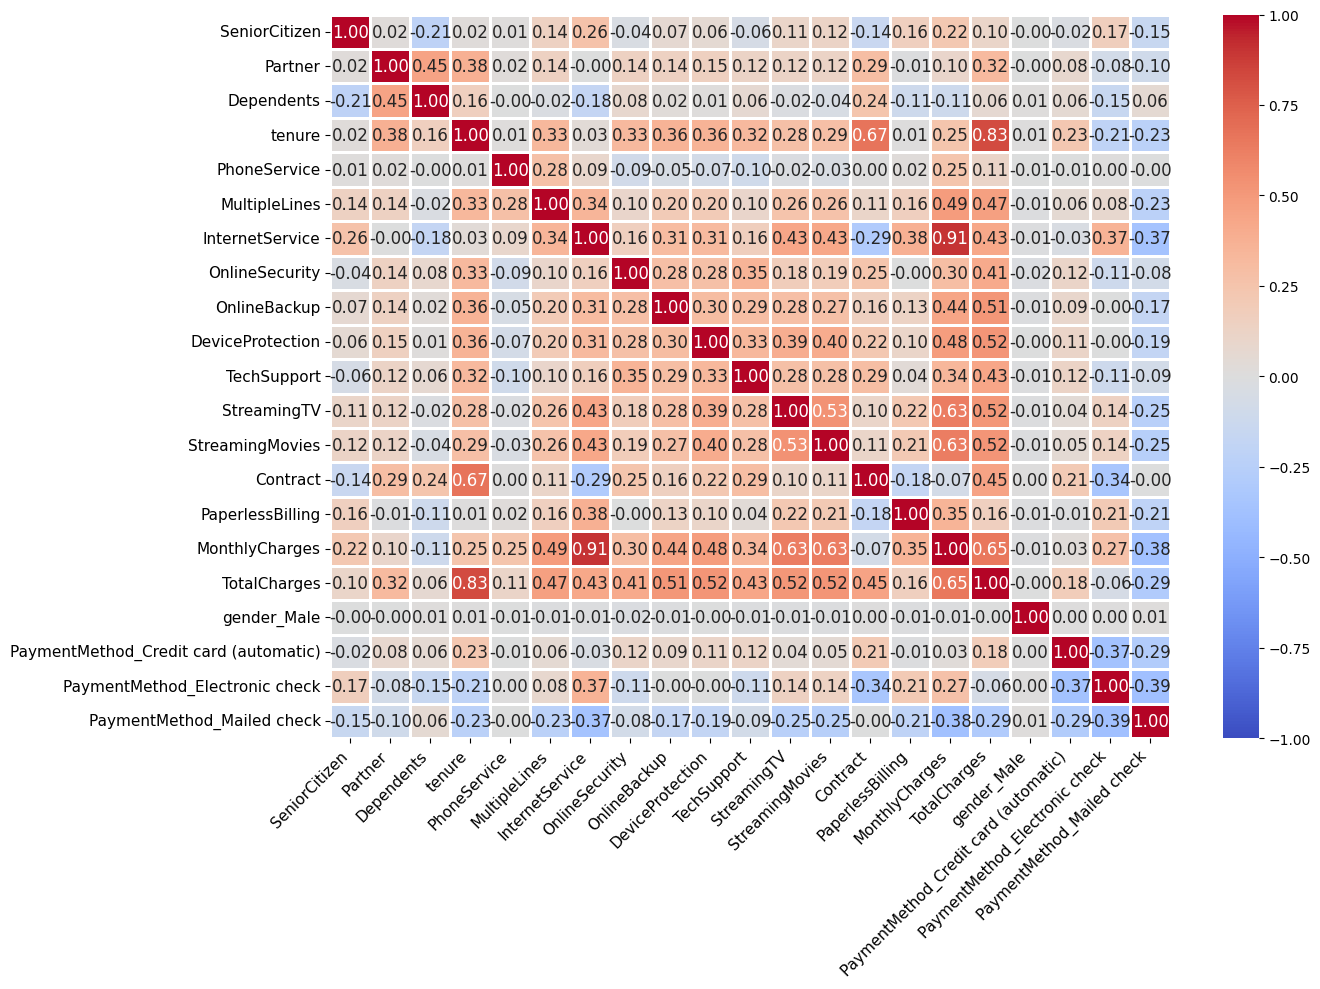

In [23]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    cbar=True,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 12},
    vmin=-1, vmax=1,
    ax=ax
)

plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

It simplifies the model by removing two columns (InternetService, TotalCharges) due to the strong correlation between InternetService and MonthlyCharges (0.91) and between TotalCharges and tenure (0.83)

In [24]:
new_df= df.copy()

In [25]:
new_df = new_df.drop(["InternetService", "TotalCharges"], axis=1, errors='ignore')
new_df

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,Churn,gender_Male,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,29.85,0,False,False,True,False
1,0,0,0,34,1,0,1,0,1,0,0,0,1,0,56.95,0,True,False,False,True
2,0,0,0,2,1,0,1,1,0,0,0,0,0,1,53.85,1,True,False,False,True
3,0,0,0,45,0,0,1,0,1,1,0,0,1,0,42.30,0,True,False,False,False
4,0,0,0,2,1,0,0,0,0,0,0,0,0,1,70.70,1,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,1,0,1,1,1,1,1,1,84.80,0,True,False,False,True
7039,0,1,1,72,1,1,0,1,1,0,1,1,1,1,103.20,0,False,True,False,False
7040,0,1,1,11,0,0,1,0,0,0,0,0,0,1,29.60,0,False,False,True,False
7041,1,1,0,4,1,1,0,0,0,0,0,0,0,1,74.40,1,True,False,False,True


In [26]:
X2 = new_df.drop("Churn", axis=1)
y2 = new_df["Churn"]
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

In [27]:
models = {
    'Logistic':             LogisticRegression(class_weight='balanced', random_state=42),
    'Random Forest':        RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
    'Extra Trees':          ExtraTreesClassifier(class_weight='balanced', random_state=42),
    'XGBoost':              XGBClassifier(scale_pos_weight=5174/1869, random_state=42),
    'LightGBM':             LGBMClassifier(class_weight='balanced', random_state=42),
    'SVM':                  SVC(kernel='rbf', class_weight='balanced', probability=True),
}

all_model_results2 = []

for name, model in models.items():

    result = cross_validate(
      model, X2, y2,
      cv=5,
      scoring=['accuracy', 'recall', 'precision', 'f1'],
      return_train_score=True
    )

    # Create a dict for the current model's results


    all_model_results2.append({
        'Model': name,
        'Accuracy': result['test_accuracy'].round(4),
        'avg_Accuracy': result['test_accuracy'].mean(),
        'Recall': result['test_recall'].round(4),
        'avg_Recall': result['test_recall'].mean(),
        'Precision': result['test_precision'].round(4),
        'avg_Precision': result['test_precision'].mean(),
        'F1': result['test_f1'].round(4),
        'avg_F1': result['test_f1'].mean(),
    })
df_results2 = pd.DataFrame(all_model_results2).set_index('Model').round(4)
avg_cols = ['avg_Accuracy', 'avg_Recall', 'avg_Precision', 'avg_F1']

df_results2.style.highlight_max(subset=avg_cols, axis=0, color='lightgreen')



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 363
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001130 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=

,Accuracy,avg_Accuracy,Recall,avg_Recall,Precision,avg_Precision,F1,avg_F1
Model,,,,,,,,
Logistic,[0.7495 0.7573 0.7374 0.7493 0.7493],0.748500,[0.8262 0.8128 0.7968 0.7802 0.7567],0.794500,[0.5176 0.5278 0.5034 0.5178 0.5193],0.517200,[0.6365 0.64 0.617 0.6225 0.6159],0.626400
Random Forest,[0.7942 0.7885 0.7715 0.7905 0.8004],0.789000,[0.4759 0.4652 0.4465 0.4531 0.5 ],0.468200,[0.6544 0.6397 0.5922 0.65 0.6655],0.640400,[0.5511 0.5387 0.5091 0.534 0.571 ],0.540800
Gradient Boosting,[0.8098 0.8034 0.7864 0.8104 0.7997],0.801900,[0.5374 0.5321 0.4947 0.5174 0.5053],0.517400,[0.6791 0.6611 0.6229 0.6893 0.6608],0.662600,[0.6 0.5896 0.5514 0.5911 0.5727],0.581000
Extra Trees,[0.7828 0.7686 0.7573 0.7699 0.7876],0.773300,[0.4599 0.4679 0.4278 0.4424 0.4947],0.458500,[0.6232 0.5795 0.5556 0.5872 0.6271],0.594500,[0.5292 0.5178 0.4834 0.5046 0.5531],0.517600
XGBoost,[0.7459 0.7715 0.7402 0.7528 0.772 ],0.756500,[0.6604 0.6765 0.639 0.6488 0.6417],0.653300,[0.5167 0.5573 0.5085 0.5272 0.5621],0.534400,[0.5798 0.6111 0.5664 0.5817 0.5993],0.587700
LightGBM,[0.7431 0.7679 0.7445 0.7486 0.7656],0.753900,[0.762 0.7406 0.7246 0.7534 0.7353],0.743200,[0.5108 0.5464 0.5133 0.5175 0.5435],0.526300,[0.6116 0.6288 0.6009 0.6135 0.625 ],0.616000
SVM,[0.7048 0.7367 0.7182 0.7152 0.7188],0.718700,[0.8075 0.7995 0.7781 0.748 0.7807],0.782800,[0.4675 0.5025 0.481 0.4761 0.4818],0.481800,[0.5922 0.6171 0.5945 0.5819 0.5959],0.596300


The analysis reveals that simplifying the model led to a marginal decrease in the most important evaluation metrics. Although both recall and accuracy were slightly lower compared to the full model, the differences were minimal and may be considered acceptable given the gains in model interpretability and reduced complexity.

In [28]:
model = LogisticRegression(class_weight='balanced', max_iter=2000, solver='saga', penalty= 'l2', C=10)
model.fit(X_train, y_train)


LogisticRegression(C=10, class_weight='balanced', max_iter=2000, solver='saga')

## Business-Aware Threshold Optimization

The `optimize_threshold_business` function finds the optimal decision threshold for a churn prediction model by incorporating real business costs. Instead of minimizing overall errors equally, it assumes that missing a churning customer (FN) is **5 times more costly** than incorrectly flagging a loyal one (FP) — reflecting the fact that acquiring a new customer is far more expensive than running a retention campaign. For each threshold between 0.01 and 0.99, the function calculates a total business cost as `(FN × 5) + (FP × 1)` and selects the threshold that minimizes this cost. This approach moves beyond standard metric optimization and directly aligns the model's decision boundary with the company's financial reality. The result is a threshold that balances churn detection with the cost of unnecessary retention actions.

### Cost Formula
Total Cost = 5 × FN + FP

In [29]:
def optimize_threshold_business(model, X_test, y_test, fn_fp_ratio=5, step=0.01):
    """
    Szuka progu maksymalizującego Recall z uwzględnieniem kosztu biznesowego.

    Założenie:
        1 FN (przeoczony klient) = koszt pozyskania nowego klienta
        1 FP (fałszywy alarm)    = koszt akcji retencyjnej
        fn_fp_ratio = 5 oznacza że FN jest 5x droższy niż FP

    Parametry:
        model        : wytrenowany model z predict_proba
        X_test       : dane testowe
        y_test       : etykiety testowe
        fn_fp_ratio  : ile razy FN jest droższy od FP
        step         : krok przeszukiwania progów
    """

    y_proba = model.predict_proba(X_test)[:, 1]
    results = []

    for threshold in np.arange(0.01, 1.0, step):
        y_pred = (y_proba >= threshold).astype(int)

        cm = confusion_matrix(y_test, y_pred)
        TN, FP, FN, TP = cm.ravel()

        # Koszt biznesowy
        koszt = (FN * fn_fp_ratio) + (FP * 1)

        recall    = recall_score(y_test, y_pred, zero_division=0)

        results.append({
            'Threshold': round(threshold, 2),
            'Recall':    round(recall, 4),
            'TP': TP, 'FP': FP,
            'TN': TN, 'FN': FN,
            'Koszt_biznesowy': koszt,
        })

    df_results = pd.DataFrame(results)

    # Najlepszy próg = minimalny koszt biznesowy
    best_row = df_results.loc[df_results['Koszt_biznesowy'].idxmin()]

    print(f"Najlepszy próg:       {best_row['Threshold']}")
    print(f"Recall:               {best_row['Recall']:.4f}")
    print(f"FN:                   {int(best_row['FN'])} (straceni klienci)")
    print(f"FP:                   {int(best_row['FP'])} (niepotrzebne akcje retencyjne)")
    print(f"Koszt biznesowy:      {int(best_row['Koszt_biznesowy'])} jednostek")

    return best_row['Threshold'], df_results




In [30]:
best_threshold, df_results = optimize_threshold_business(
    model       = model,
    X_test      = X_test,
    y_test      = y_test,
    fn_fp_ratio = 5,
    step        = 0.01
)

Najlepszy próg:       0.33
Recall:               0.9171
FN:                   31 (straceni klienci)
FP:                   436 (niepotrzebne akcje retencyjne)
Koszt biznesowy:      591 jednostek


In [31]:
y_pred = (model.predict_proba(X_test)[:, 1] >= 0.33).astype(int)

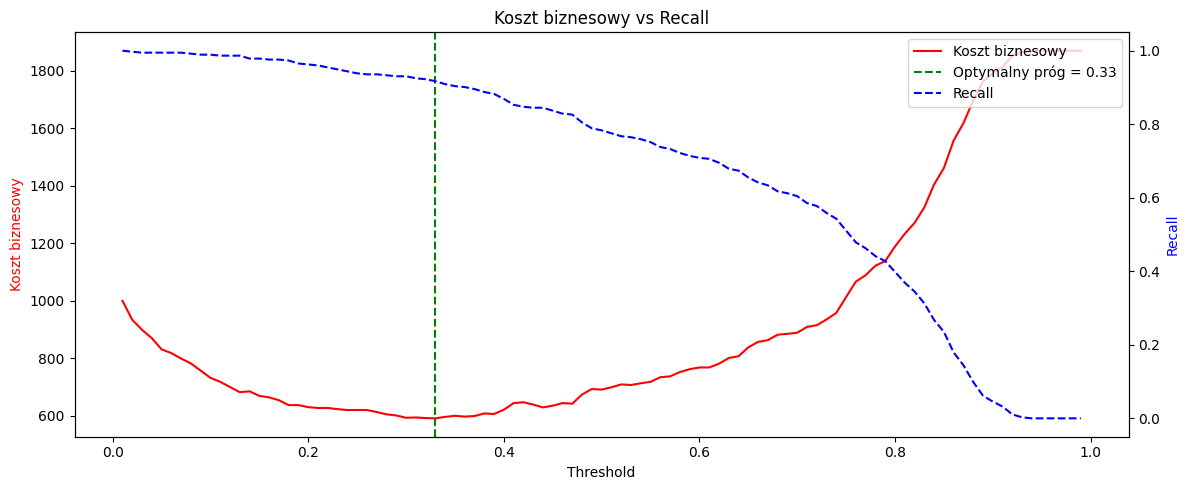

In [32]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Koszt biznesowy
ax1.plot(df_results['Threshold'], df_results['Koszt_biznesowy'],
         color='red', label='Koszt biznesowy')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Koszt biznesowy', color='red')

# Recall
ax2 = ax1.twinx()
ax2.plot(df_results['Threshold'], df_results['Recall'],
         color='blue', label='Recall', linestyle='--')
ax2.set_ylabel('Recall', color='blue')

# Optymalny próg
ax1.axvline(x=best_threshold, color='green',
            linestyle='--', label=f'Optymalny próg = {best_threshold}')

fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)
plt.title('Koszt biznesowy vs Recall')
plt.tight_layout()
plt.show()

# Logika funkcji kosztu:
# Koszt = (FN × 5) + (FP × 1)


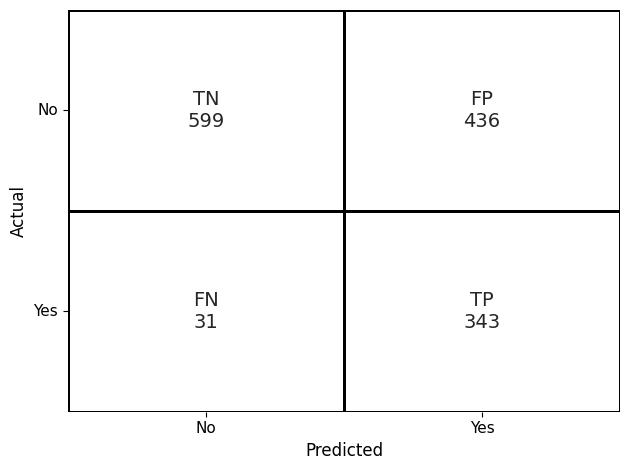

In [33]:
cm = confusion_matrix(y_test, y_pred)

labels = [['TN', 'FP'],
          ['FN', 'TP']]

annot = [[f"{labels[i][j]}\n{cm[i][j]}" for j in range(2)] for i in range(2)]

sns.heatmap(
    cm,
    annot=annot,
    fmt='',
    cmap=['white'],
    linewidths=2,
    linecolor='black',
    cbar=False,
    annot_kws={'size': 14}
)

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.xticks([0.5, 1.5], ['No', 'Yes'], fontsize=11)
plt.yticks([0.5, 1.5], ['No', 'Yes'], fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

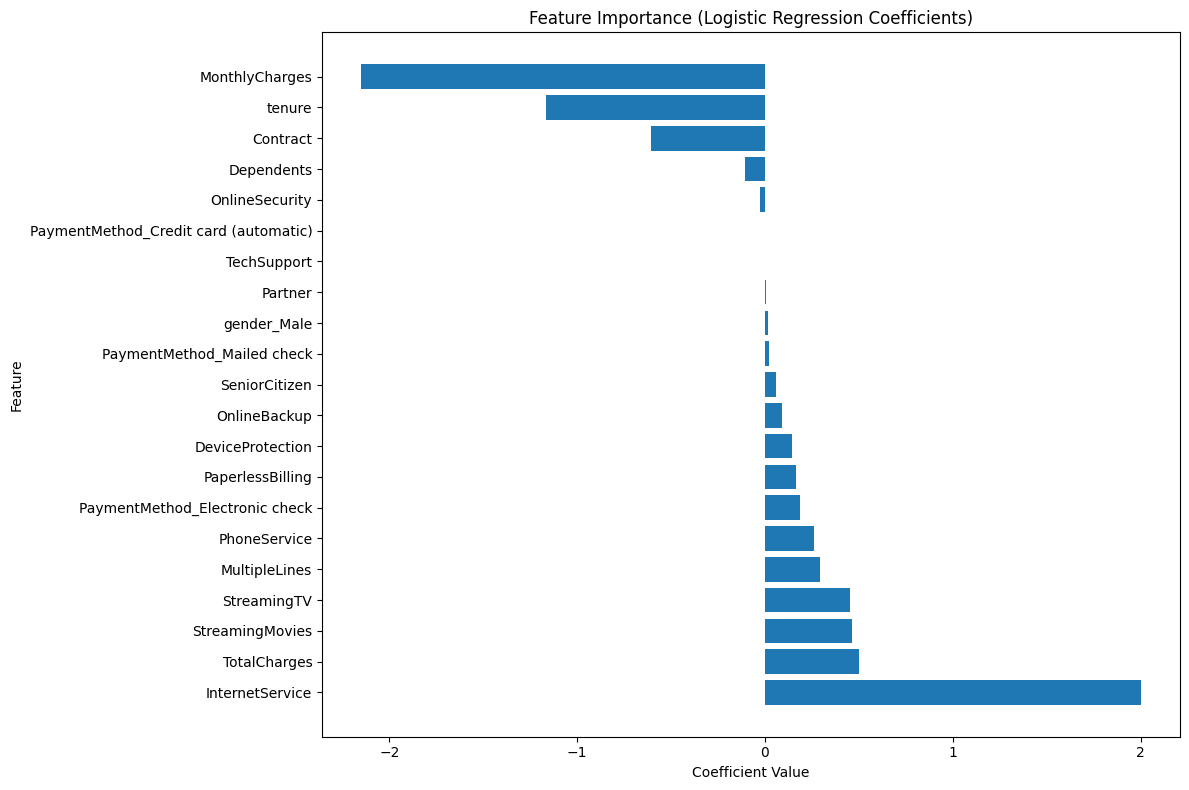

In [34]:
feature_importance = model.coef_[0]
feature_names = X.columns

# Create a pandas Series for easier manipulation and sorting
feat_series = pd.Series(feature_importance, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feat_series.index, feat_series.values)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

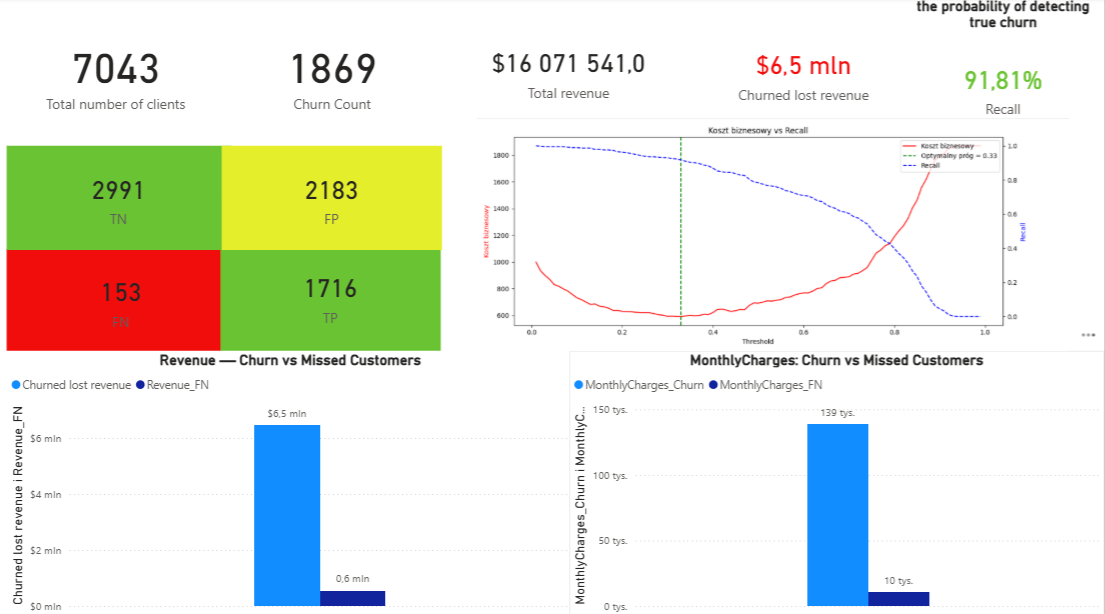

Business Recommendations:

- Target retention efforts at customers with month-to-month and fiber optic contracts—the highest churn risk
- Implement a model with a threshold of 0.3–0.5 to maximize detection rates
- Proactively offer longer-term contracts to customers with a high likelihood of churn before they decide to leave
- Monitor customers with short tenure—new customers are most at risk of churning